In [12]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

In [13]:
from dotenv import load_dotenv

load_dotenv()
DATA_PATH = os.getenv("DATA_PATH")
MODELS_PATH = os.path.join(os.path.dirname(DATA_PATH), "models")
RESULTS_PATH = os.path.join(os.path.dirname(DATA_PATH), "results")
PLOTS_PATH = os.getenv("PLOTS_PATH")

In [14]:
# carregando dataset de model1
df = pd.read_parquet(os.path.join(DATA_PATH, "model1_dataset.parquet"))
df.head()

,player_id,date,market_value_in_eur,height_in_cm,international_caps,international_goals,national_team_ranking_inv,position_rank,sub_pos_Attacking Midfield,sub_pos_Central Midfield,...,assists_per_90,minutes_per_game,squad_size,net_transfer_record,national_team_players,stadium_seats,league_tier,club_computed_market_value,year,log_market_value
0,6893,2003-12-15,900000,188.0,0.0,0.0,0,2,False,False,...,0.0,0.0,25,-1350000.0,4,26850,1,0.0,2003,13.710151
1,14007,2004-10-04,750000,177.0,0.0,0.0,0,3,False,False,...,0.0,0.0,26,900000.0,8,18360,1,0.0,2004,13.527830
2,13957,2004-10-04,2000000,182.0,0.0,0.0,0,1,False,False,...,0.0,0.0,0,-0.0,0,5441,4,0.0,2004,14.508658
3,13952,2004-10-04,2000000,175.0,0.0,0.0,0,4,False,False,...,0.0,0.0,27,-24490000.0,12,50033,4,0.0,2004,14.508658
4,13894,2004-10-04,500000,193.0,0.0,0.0,0,1,False,False,...,0.0,0.0,26,-0.0,2,8432,4,0.0,2004,13.122365


In [15]:
# filtrando conjunto de teste (a partir de 2024)
df_test = df[df["date"] >= "2024-01-01"].copy()
print(f"amostras de teste: {len(df_test):,}")

amostras de teste: 65,334


In [16]:
# carregando lista de features usadas no treino
with open(os.path.join(MODELS_PATH, "feature_names_model1.pkl"), "rb") as f:
    feature_names = pickle.load(f)

X_test = df_test[feature_names]
y_test_log = df_test["log_market_value"]

In [17]:
# carregando modelo xgboost salvo
model = xgb.XGBRegressor()
model_path = os.path.join(MODELS_PATH, "model1_market_value.json")
model.load_model(model_path)

In [18]:
# gerando predições no conjunto de teste (escala log)
pred_log = model.predict(X_test)

# revertendo escala logarítmica (expm1 é o inverso de log1p)
y_pred = np.expm1(pred_log)
y_real = np.expm1(y_test_log)

df_test["y_pred_log"] = pred_log
df_test["y_pred"] = y_pred
df_test["y_real"] = y_real

In [19]:
# salvando csv de predições
df_preds = df_test[["player_id", "date", "y_real", "y_pred"]]
df_preds.to_csv(os.path.join(RESULTS_PATH, "predictions_test_model1.csv"), index=False)

In [20]:
# calculando métricas no conjunto de teste
mae = mean_absolute_error(y_real, y_pred)
mape = mean_absolute_percentage_error(y_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
r2_log = r2_score(y_test_log, pred_log)
r2_real = r2_score(y_real, y_pred)

metrics = {"MAE": mae, "MAPE": mape, "RMSE": rmse, "R2_log": float(r2_log), "R2_real": float(r2_real)}

with open(os.path.join(RESULTS_PATH, "metrics_model1.json"), "w") as f:
    json.dump(metrics, f, indent=4)

print(f"MAE: € {mae:,.2f}")
print(f"MAPE: {mape:.2%}")
print(f"RMSE: € {rmse:,.2f}")
print(f"R² (log) : {r2_log:.4f}")
print(f'R²: {r2_real:.4f}')

MAE: € 2,377,153.59
MAPE: 50.64%
RMSE: € 5,932,344.71
R² (log) : 0.7006
R²: 0.7086


In [21]:
# comparando mape com baseline histórico
with open(os.path.join(RESULTS_PATH, "baseline_model1_metrics.json"), "r") as f:
    baseline_metrics = json.load(f)
melhoria = (baseline_metrics["MAPE_pct"] - mape) / baseline_metrics["MAPE_pct"]
print(f"melhoria do MAPE em relação ao baseline: {melhoria:.2%} (redução do erro)")

melhoria do MAPE em relação ao baseline: 99.28% (redução do erro)


In [22]:
# calculando shap values com tree explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

with open(os.path.join(RESULTS_PATH, "shap_values_model1.pkl"), "wb") as f:
    pickle.dump(shap_values, f)

In [23]:
# criando coluna de erro percentual absoluto
df_test["ape"] = np.abs((df_test["y_real"] - df_test["y_pred"]) / df_test["y_real"])

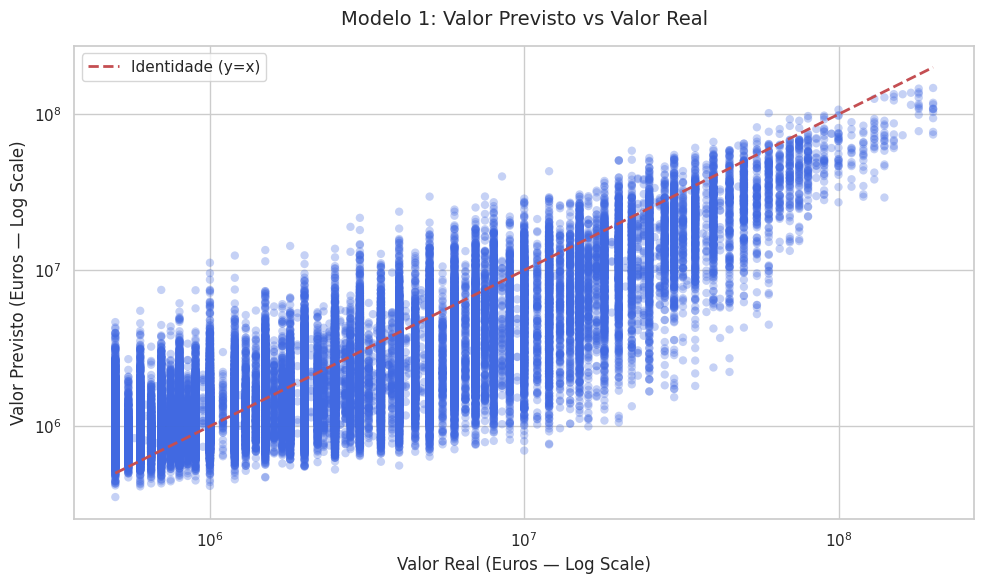

In [24]:
# scatter plot: valor previsto vs valor real (escala log)
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df_test["y_real"],
    df_test["y_pred"],
    alpha=0.3,
    color="royalblue",
    edgecolors="none",
)
lims = [df_test["y_real"].min(), df_test["y_real"].max()]
ax.plot(lims, lims, "r--", lw=2, label="Identidade (y=x)")
ax.set_xscale("log")
ax.set_yscale("log")

# Customização de títulos e eixos
ax.set_xlabel("Valor Real (Euros — Log Scale)", fontsize=12)
ax.set_ylabel("Valor Previsto (Euros — Log Scale)", fontsize=12)
ax.set_title("Modelo 1: Valor Previsto vs Valor Real", fontsize=14, pad=15)
ax.legend()

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_predicted_vs_real.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

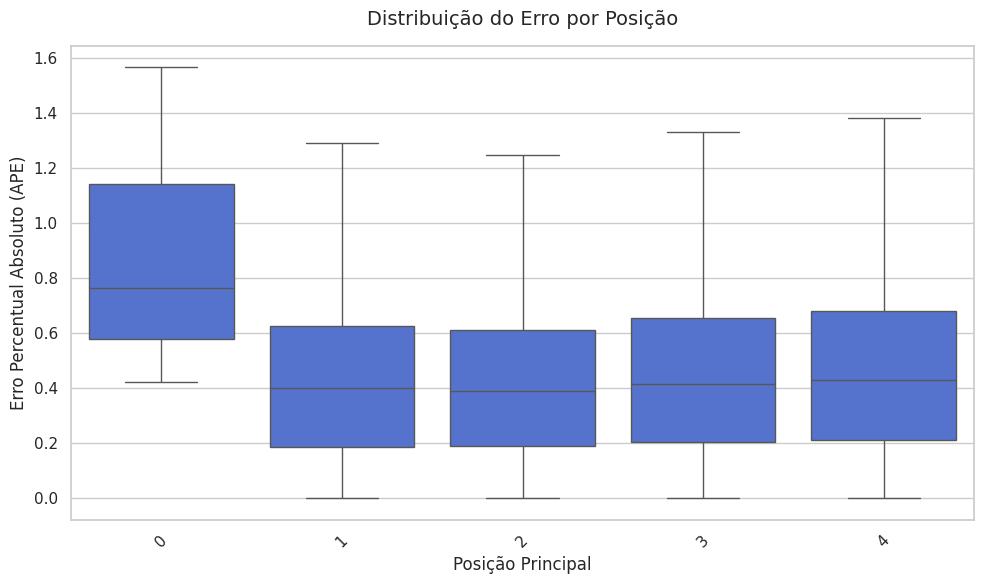

In [25]:
# boxplot de erro por posição
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_test, x="position_rank", y="ape", showfliers=False, color="royalblue", ax=ax
)

# Customização de títulos e eixos
ax.set_xlabel("Posição Principal", fontsize=12)
ax.set_ylabel("Erro Percentual Absoluto (APE)", fontsize=12)
ax.set_title("Distribuição do Erro por Posição", fontsize=14, pad=15)
plt.xticks(rotation=45)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_residuals_by_position.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

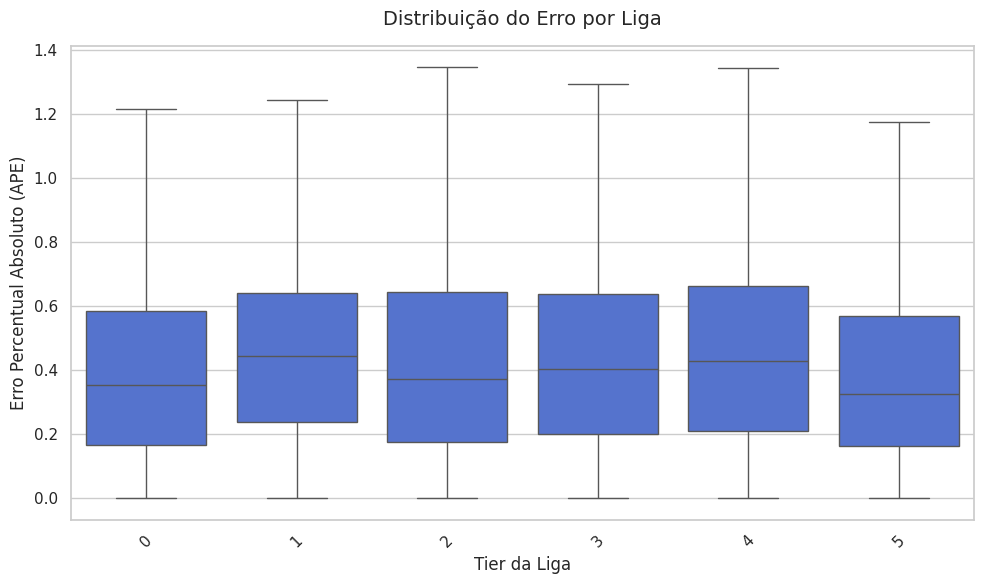

In [26]:
# boxplot de erro por liga
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_test, x="league_tier", y="ape", showfliers=False, color="royalblue", ax=ax
)

# Customização de títulos e eixos
ax.set_xlabel("Tier da Liga", fontsize=12)
ax.set_ylabel("Erro Percentual Absoluto (APE)", fontsize=12)
ax.set_title("Distribuição do Erro por Liga", fontsize=14, pad=15)
plt.xticks(rotation=45)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_residuals_by_league.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [27]:
# criando faixas etárias para análise de erro
df_test["age_group"] = pd.cut(
    df_test["age"],
    bins=[0, 19, 24, 29, 100],
    labels=["Sub-20", "20-24", "25-29", "30+"],
    right=True,
)

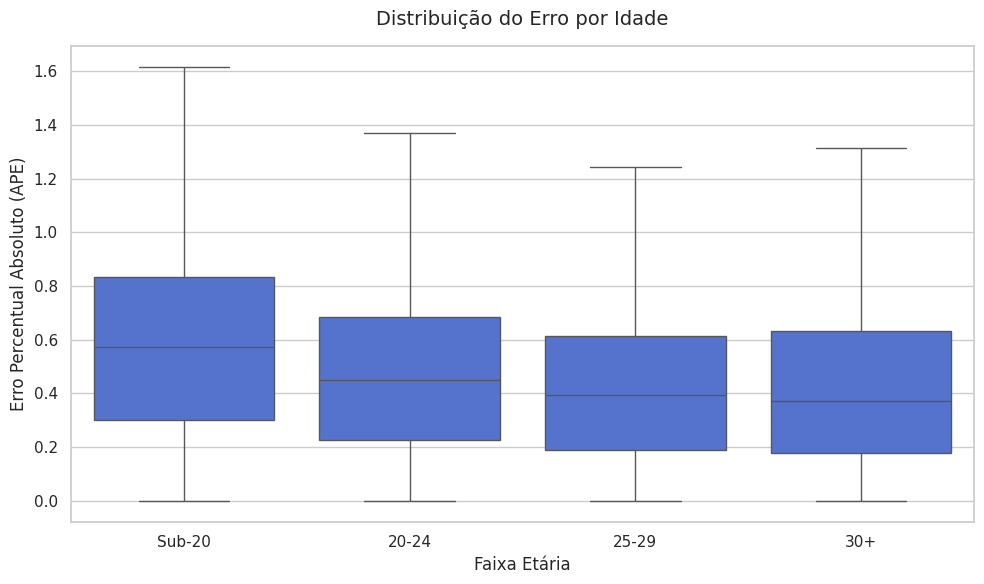

In [28]:
# boxplot de erro por faixa etária
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_test, x="age_group", y="ape", showfliers=False, color="royalblue", ax=ax
)

# Customização de títulos e eixos
ax.set_xlabel("Faixa Etária", fontsize=12)
ax.set_ylabel("Erro Percentual Absoluto (APE)", fontsize=12)
ax.set_title("Distribuição do Erro por Idade", fontsize=14, pad=15)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_error_by_age.png"), dpi=300, bbox_inches="tight"
)
plt.show()

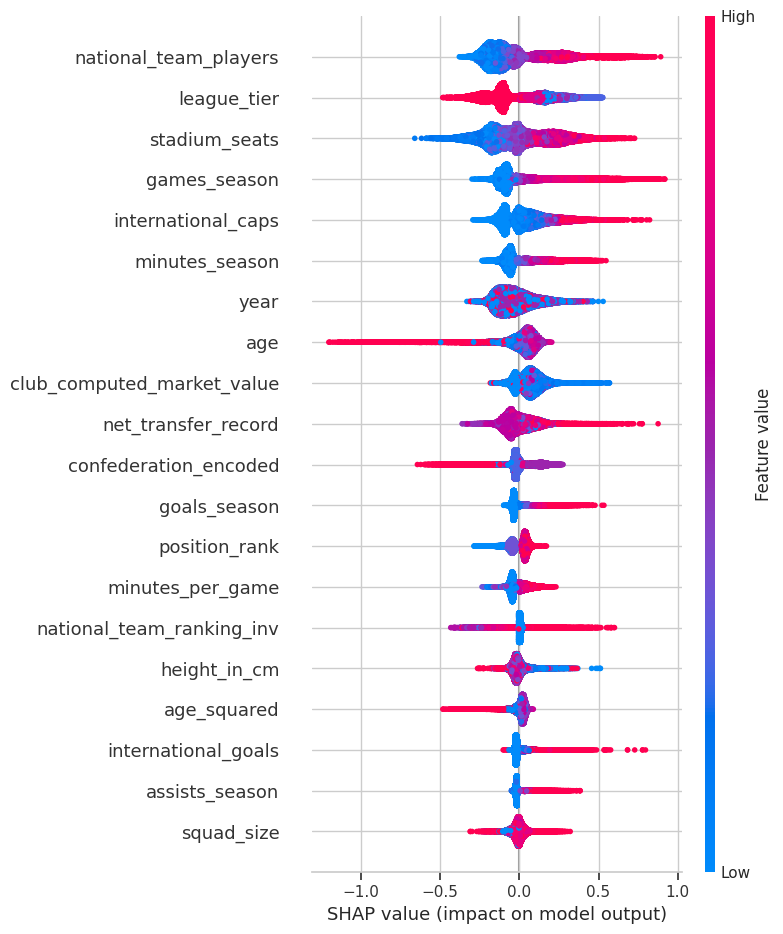

In [29]:
# shap summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_shap_summary.png"), dpi=300, bbox_inches="tight"
)
plt.show()

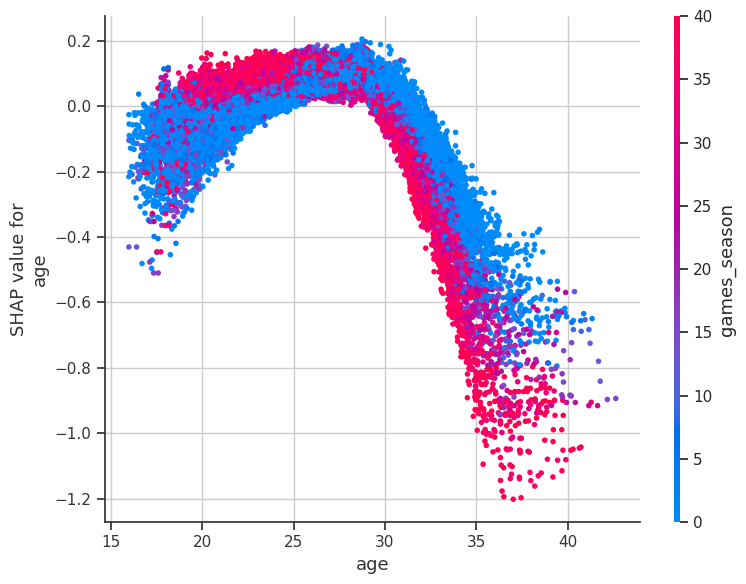

In [30]:
# shap dependence plot para age
shap_data = shap_values.values if hasattr(shap_values, "values") else shap_values

fig, ax = plt.subplots(figsize=(8, 6))
shap.dependence_plot("age", shap_data, X_test, show=False, ax=ax)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_shap_dependence_age.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

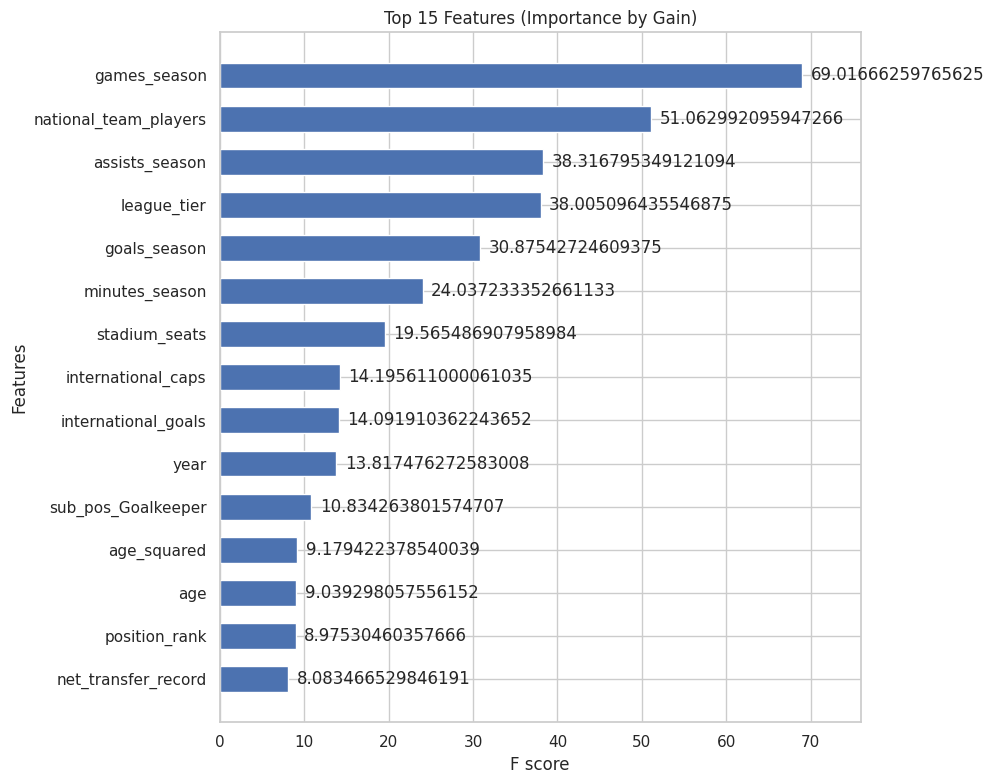

In [31]:
# feature importance nativa do xgboost (gain)
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(
    model,
    max_num_features=15,
    height=0.6,
    importance_type="gain",
    title="Top 15 Features (Importance by Gain)",
    ax=ax,
)

# Exibe o gráfico e salva
plt.tight_layout()
plt.savefig(
    os.path.join(PLOTS_PATH, "model1_feature_importance.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [32]:
# calculando erro absoluto e isolando top 10 piores predições
df_test["absolute_error"] = np.abs(df_test["y_real"] - df_test["y_pred"])
top_10_errors = df_test.nlargest(10, "absolute_error")

cols_to_show = [
    "player_id",
    "date",
    "age",
    "league_tier",
    "position_rank",
    "y_real",
    "y_pred",
    "absolute_error",
    "ape",
]
display(top_10_errors[cols_to_show])

,player_id,date,age,league_tier,position_rank,y_real,y_pred,absolute_error,ape
320774,937958,2025-12-12,18.417522,2,4,200000000.0,74155832.0,125844168.0,0.629221
309457,937958,2025-06-09,17.908282,2,4,200000000.0,77085160.0,122914840.0,0.614574
316624,349066,2025-10-17,26.072553,1,4,140000000.0,29256998.0,110743002.0,0.791021
339183,937958,2026-06-05,18.896646,2,4,200000000.0,94390344.0,105609656.0,0.528048
299648,937958,2024-12-27,17.459274,2,4,180000000.0,77923488.0,102076512.0,0.567092
295820,418560,2024-12-16,24.405202,1,4,200000000.0,103410192.0,96589808.0,0.482949
335824,502670,2026-06-01,25.297741,3,4,140000000.0,46468064.0,93531936.0,0.668085
335584,670681,2026-06-01,21.675565,3,3,140000000.0,47646664.0,92353336.0,0.659667
318707,418560,2025-12-09,25.385352,1,4,200000000.0,107912568.0,92087432.0,0.460437
289389,418560,2024-10-01,24.197125,1,4,200000000.0,107995136.0,92004864.0,0.460024


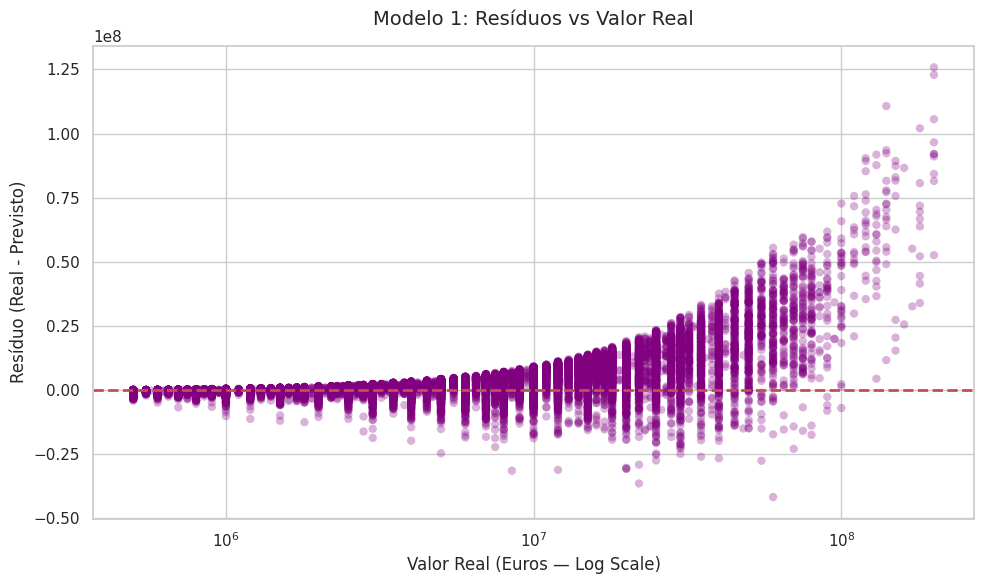

In [33]:
# 1. Scatter plot: Erros (Resíduos) vs Valor Real
df_test["residual"] = df_test["y_real"] - df_test["y_pred"]
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_test["y_real"], df_test["residual"], alpha=0.3, color="purple", edgecolors="none")
ax.axhline(0, color="r", linestyle="--", lw=2)
ax.set_xscale("log")
ax.set_xlabel("Valor Real (Euros — Log Scale)", fontsize=12)
ax.set_ylabel("Resíduo (Real - Previsto)", fontsize=12)
ax.set_title("Modelo 1: Resíduos vs Valor Real", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model1_residuals_vs_real.png"), dpi=300, bbox_inches="tight")
plt.show()

In [34]:
# 2. Boxplots de MAPE (APE) por faixa de valor
bins = [0, 1e6, 5e6, 20e6, float('inf')]
labels = ["<1M", "1M-5M", "5M-20M", ">20M"]
df_test["value_group"] = pd.cut(df_test["y_real"], bins=bins, labels=labels, right=False)

/tmp/ipykernel_606035/1072032015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_test, x="value_group", y="ape", showfliers=False, palette="Set2", ax=ax)


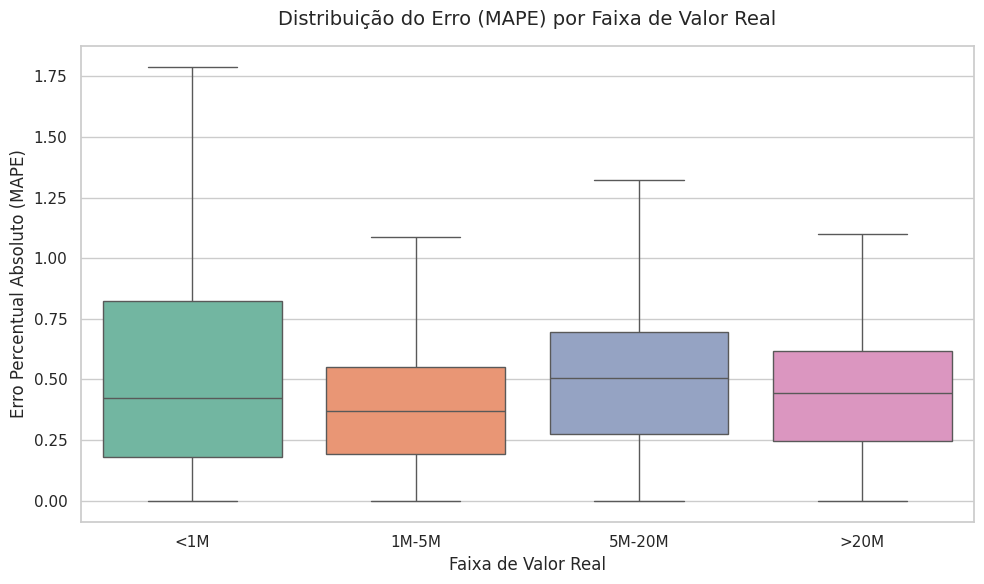

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_test, x="value_group", y="ape", showfliers=False, palette="Set2", ax=ax)
ax.set_xlabel("Faixa de Valor Real", fontsize=12)
ax.set_ylabel("Erro Percentual Absoluto (MAPE)", fontsize=12)
ax.set_title("Distribuição do Erro (MAPE) por Faixa de Valor Real", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model1_mape_by_value_group.png"), dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# 3. Matriz de Confusão de Predição (Crosstab)
df_test["pred_group"] = pd.cut(df_test["y_pred"], bins=bins, labels=labels, right=False)
conf_matrix = pd.crosstab(df_test["value_group"], df_test["pred_group"], rownames=["Real"], colnames=["Previsto"])

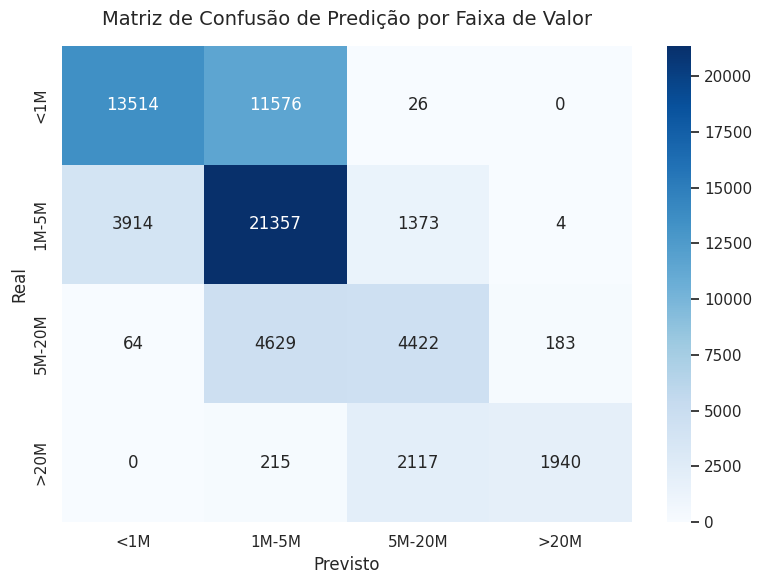

In [37]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de Confusão de Predição por Faixa de Valor", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_PATH, "model1_prediction_confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()